In [1]:
%load_ext autoreload
%autoreload 2

In [80]:
import tpvalidator.datacatalogue as dsl
datasets = dsl.load('data/vd/1x8x14/wct_test')
# datasets = dsl.load('data/vd/1x8x14/preprod')

mm_z = datasets['muminus_tomoz']
# mm_z = datasets['eminus']

Loading muminus_tomoz

Dataset 'muminus_tomoz': 5 events

{
    'backtracker': {'TPAlgTPCSimpleThreshold': {'offset_U': 8, 'offset_V': 1, 'offset_X': -7}},
    'geo': {'detector': 'dunevd10kt_3view_30deg_v5_refactored_1x8x14ref'},
    'mctruth_blockid_map': [[0, 'generator']],
    'tpg': {
        'tpmakerTPCSimpleThreshold::TriggerPrimitiveMaker': {
            'threshold_tpg_plane0': 36,
            'threshold_tpg_plane1': 36,
            'threshold_tpg_plane2': 36,
            'tool': 'TPAlgTPCSimpleThreshold'
        }
    }
}

In [81]:
from tpvalidator.viz.display import TriggerPrimitivesEventViewer

tpv = TriggerPrimitivesEventViewer(mm_z)


In [84]:
mu_entry = 3

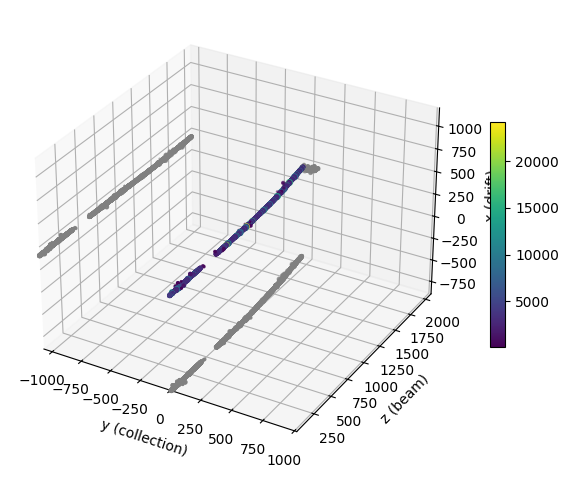

In [85]:
fig = tpv.draw_tps_point_of_origin(mm_z.event_summary.event_uid[mu_entry])

In [86]:
import tpvalidator.detgeometry as detgeo

g = detgeo.get_by_geocfg_id(mm_z.info['geo']['detector'])



In [87]:
g.num_drifts

1

In [88]:
x = tpv.decorate_tpc_coords().query(f'entry=={mu_entry} & readout_plane_id == 2 & bt_is_signal==1')


3 4
8


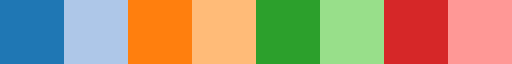

<Axes: xlabel='tpc_z_channel', ylabel='sample_start'>

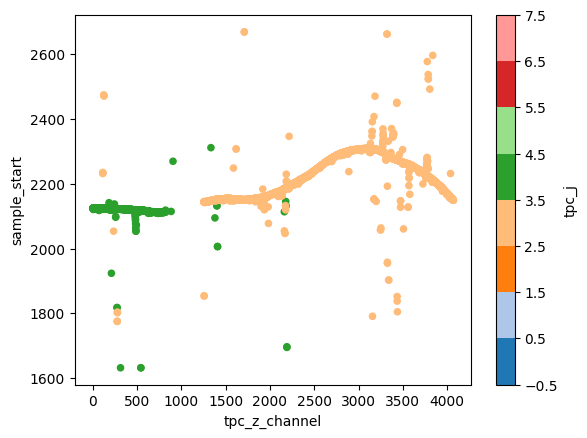

In [89]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


jmin, jmax = x.tpc_j.min(), x.tpc_j.max()
print(jmin, jmax)


jmin, jmax = 0, g.num_y_rows-1
n = jmax-jmin+1
print(n)

tab10_colors = plt.get_cmap('tab20').colors
cmap = mcolors.ListedColormap(tab10_colors[:n])
norm = mcolors.BoundaryNorm(boundaries=np.arange(jmin-0.5, jmax + 0.5+1, 1), ncolors=n)


# cmap = plt.get_cmap('viridis', n)  # discretize into n distinct colors
# norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, n + 0.5, 1), ncolors=n)


display(cmap)


x.plot.scatter(x='tpc_z_channel', y='sample_start', c='tpc_j', cmap=cmap, norm=norm)

In [94]:
print(x.event_uid)

entry  subentry
3      314         1234000000104
       315         1234000000104
       318         1234000000104
       319         1234000000104
       321         1234000000104
                       ...      
       10066       1234000000104
       10071       1234000000104
       10072       1234000000104
       10073       1234000000104
       10074       1234000000104
Name: event_uid, Length: 3797, dtype: uint64


In [90]:
mm_z.mctruths.query('kinetic_energy > 0.1')



,,event,run,subrun,pdg,process,status_code,block_id,truth_track_id,generator_name,x,y,z,t,px,py,pz,p,energy,kinetic_energy,event_uid
entry,subentry,,,,,,,,,,,,,,,,,,,,
0,0,1,1234000,1,13,primary,1,0,-1,generator,45.110783,585.321748,0.0,0.0,0.0,0.0,8.0,8.0,8.000698,7.89504,1234000000101
1,0,2,1234000,1,13,primary,1,0,-1,generator,-273.120424,-118.283569,0.0,0.0,0.0,0.0,8.0,8.0,8.000698,7.89504,1234000000102
2,0,3,1234000,1,13,primary,1,0,-1,generator,-242.681816,-256.860963,0.0,0.0,0.0,0.0,8.0,8.0,8.000698,7.89504,1234000000103
3,0,4,1234000,1,13,primary,1,0,-1,generator,154.533312,6.956297,0.0,0.0,0.0,0.0,8.0,8.0,8.000698,7.89504,1234000000104
4,0,5,1234000,1,13,primary,1,0,-1,generator,45.624205,123.357564,0.0,0.0,0.0,0.0,8.0,8.0,8.000698,7.89504,1234000000105


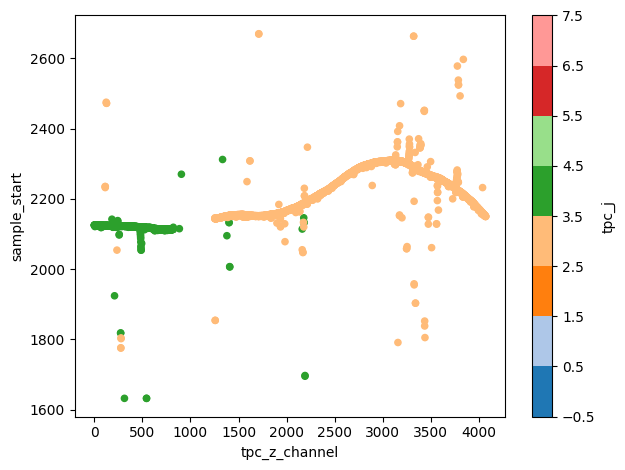

In [95]:
fig = tpv.plot_yzt_event_view(1234000000104)